# Stroke Prediction Analysis

## Sprint 1 – Data Understanding & Preparation


## 1. Business Understanding

### Business Objective

The objective of this project is to study healthcare data and find the main factors associated with stroke occurrence. 
The analysis helps doctors and hospitals understand patients better and support early prevention and treatment.

### Expected Outcome

The expected outcome is to identify the health, personal, and lifestyle factors related to stroke, prepare a clean dataset for analysis, and provide useful insights that help improve healthcare decisions.


##  2. Dataset Understanding

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#Loading Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [24]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 5110
Number of Columns : 12


In [5]:
# Features available
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


The dataset contains 12 features. 

These features give information about the patient's health, personal details, and lifestyle.

In [6]:
target_variable = "stroke"
print("Target Variable:", target_variable)

Target Variable: stroke


### Target Variable

The Target Variable is stroke. It indicates whether a patient has experienced a stroke or not.

0 -> No Stroke

1 -> Stroke

In [7]:
#Numerical Columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')


### Numerical Columns

The numerical columns are age, hypertension, heart_disease, avg_glucose_level, bmi, and stroke. These columns contain numbers and will be used for calculations, analysis, and graphs.
where id is a unique identifier and not useful for analysis

In [42]:
#Categorical Columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


### Categorical Columns

The categorical columns are gender, ever_married, work_type, Residence_type, and smoking_status.
These columns contain different categories of patient information and will be used to compare different groups.

## 3. DataFrame Exploration

This section helps us understand the dataset before cleaning and analysis.

In [9]:
# Shape of dataset
print(df.shape)

# Display the number of rows
print("Number of Rows:", df.shape[0])

# Display the number of columns
print("Number of Columns:", df.shape[1])

(5110, 12)
Number of Rows: 5110
Number of Columns: 12


The dataset contains 5,110 rows and 12 columns

In [10]:
# Data type of each column
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


The dataset contains int64, float64, and object data types. 

Integer and float columns contain numerical values, while object columns contain text values.

In [11]:
# Column information
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


The dataset contains 12 columns. 

These columns include patient details, health information, lifestyle information, and the target variable (stroke).

In [12]:
# Summary statistics of numerical columns
print(df.describe())

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

The summary statistics show the count, mean, standard deviation, minimum, maximum, and quartile values of the numerical columns. These values help us understand the data before analysis.

Count → Number of values

Mean → Average value

Std → Standard deviation

Min → Minimum value

25% → First quartile

50% → Median

75% → Third quartile

Max → Maximum value

### Overall Structure of the Dataset
The dataset has 5110 rows and 12 columns. It contains both numerical and categorical data.

The features include patient details, health information, and lifestyle information.

The target variable is stroke, which is used to identify whether a patient had a stroke or not.

##  4. Data Cleaning

In [13]:
# Missing values in each column
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Only the bmi column contains missing values (201). All other columns have no missing values.

In [25]:
# Fill missing BMI values with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

The missing values in the bmi column are replaced with the median BMI value.

Median was used because it is less affected by extreme values.

In [27]:
# Check missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


After filling the missing BMI values, all columns contain 0 missing values.

In [39]:
# Check duplicate records
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


duplicated().sum() counts the number of completely duplicate rows in the dataset.

The dataset contains 0 duplicate records.
No changes were made because there are no duplicate records.

In [15]:
# Check data types
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


dtypes shows the type of data stored in each column. We check this to make sure every column has a suitable data type for analysis.

The numerical columns have int64 or float64 data types, and the categorical columns have object data type.

All columns have appropriate data types. No changes are required.

In [16]:
# Check unique values in categorical columns
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(col)
    print(df[col].unique())

gender
['Male' 'Female' 'Other']
ever_married
['Yes' 'No']
work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type
['Urban' 'Rural']
smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


The categorical columns contain valid values. No invalid entries were found in the dataset.

No changes were made because all values are valid.

In [6]:
# Check for invalid numerical values

print("Negative age values:", (df['age'] < 0).sum())
print("Negative BMI values:", (df['bmi'] < 0).sum())
print("Negative glucose values:", (df['avg_glucose_level'] < 0).sum())

# Check binary columns
print("Invalid hypertension values:",
      (~df['hypertension'].isin([0, 1])).sum())

print("Invalid heart_disease values:",
      (~df['heart_disease'].isin([0, 1])).sum())

print("Invalid stroke values:",
      (~df['stroke'].isin([0, 1])).sum())

Negative age values: 0
Negative BMI values: 0
Negative glucose values: 0
Invalid hypertension values: 0
Invalid heart_disease values: 0
Invalid stroke values: 0


No invalid negative values were found in age, BMI, or average glucose level. The binary variables hypertension, heart disease, and stroke contain only valid 0/1 values. 
    
Therefore, no additional corrections were required for these variables.

In [17]:
# Inconsistent Categorical Values
# Check the unique values and their counts in categorical columns

for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(f"\n{col}:")
    print(df[col].value_counts().rename_axis(None).to_string())


gender:
Female    2994
Male      2115
Other        1

ever_married:
Yes    3353
No     1757

work_type:
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22

Residence_type:
Urban    2596
Rural    2514

smoking_status:
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789


The categorical values are consistent. No spelling mistakes or formatting differences were found in the categorical columns.

No changes were made because the categorical values are already consistent.

### Observation
The dataset was checked for missing values, duplicates, incorrect data types, invalid values, and inconsistent categorical values. The required cleaning was performed and the dataset is ready for further analysis.

##  5. Outlier Analysis

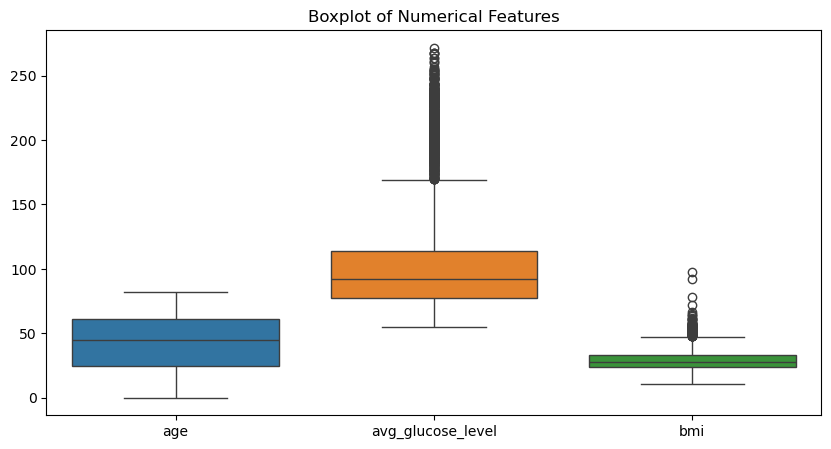

In [18]:
# Check outliers in numerical columns using boxplots

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['age', 'avg_glucose_level', 'bmi']])
plt.title("Boxplot of Numerical Features")
plt.show()

In [34]:
# Find the number of outliers using IQR method

for col in ['age', 'avg_glucose_level', 'bmi']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    print(col)
    print("Number of outliers:", len(outliers))
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print()

age
Number of outliers: 0
Lower limit: -29.0
Upper limit: 115.0

avg_glucose_level
Number of outliers: 627
Lower limit: 21.977500000000006
Upper limit: 169.35750000000002

bmi
Number of outliers: 126
Lower limit: 10.300000000000006
Upper limit: 46.29999999999999



The IQR method identifies values that are unusually low or high compared with the middle 50% of the data.

Age: 0 outliers

Average glucose level: 627 outliers

BMI: 110 outliers

The age column has no outliers. The avg_glucose_level column has 627 outliers, and the bmi column has 110 outliers.

Cleaning Decision

The outliers in avg_glucose_level and bmi will not be removed because these values can represent actual patient health conditions. Removing them may result in loss of important information.

## 6. Data Validation

In [37]:
# Check the final dataset

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

Missing Values:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Duplicate Records:
0

Data Types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Dataset Shape:
(5110, 12)


### Observation

The final dataset contains 5110 rows and 12 columns. There are no missing values and no duplicate records. The columns have appropriate data types, with numerical columns stored as int64 or float64 and categorical columns stored as object.

### Validation Decision

No further changes are required. The dataset has passed the final validation checks and is ready for analysis.

## 7. Initial Business Observations

In [40]:
# Check the distribution of stroke
print(df['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


The stroke column is our target variable:

0 → Patient did not have a stroke

1 → Patient had a stroke

### Observation

The dataset contains 4861 patients without stroke and 249 patients with stroke. This shows that the number of patients without stroke is much higher than the number of patients with stroke.

### Business Insight

The target variable is imbalanced, with fewer stroke cases compared to non-stroke cases. This should be considered during further analysis.

### Overall Initial Observations

The dataset contains 5110 patient records and 12 columns.
    
Missing values were found in the bmi column and were handled using the median.
    
No duplicate records were found.
    
Some outliers were found in avg_glucose_level and bmi, but they were retained because they may represent actual patient values.

The final dataset has no missing values and is ready for further analysis.

In [76]:
df.to_csv('stroke_cleaned.csv', index=False)